# Exercise 2: Random numbers

In [219]:
import numpy as np
import matplotlib.pyplot as plt

In [220]:
colors = ['#E63946', '#F1FAEE', '#A8DADC', '#457B9D', '#1D3557', '#C92A35', '#0E2A47']

In [221]:
# Random number generator (numbers between 0 and 1)
def random_number(dimensions):
    uniform = np.random.rand(dimensions)
    gaussian = np.random.randn(dimensions)
    exponential = np.random.exponential(1, dimensions)
    return uniform, gaussian, exponential

Text(0.5, 1.0, 'Exponential distribution')

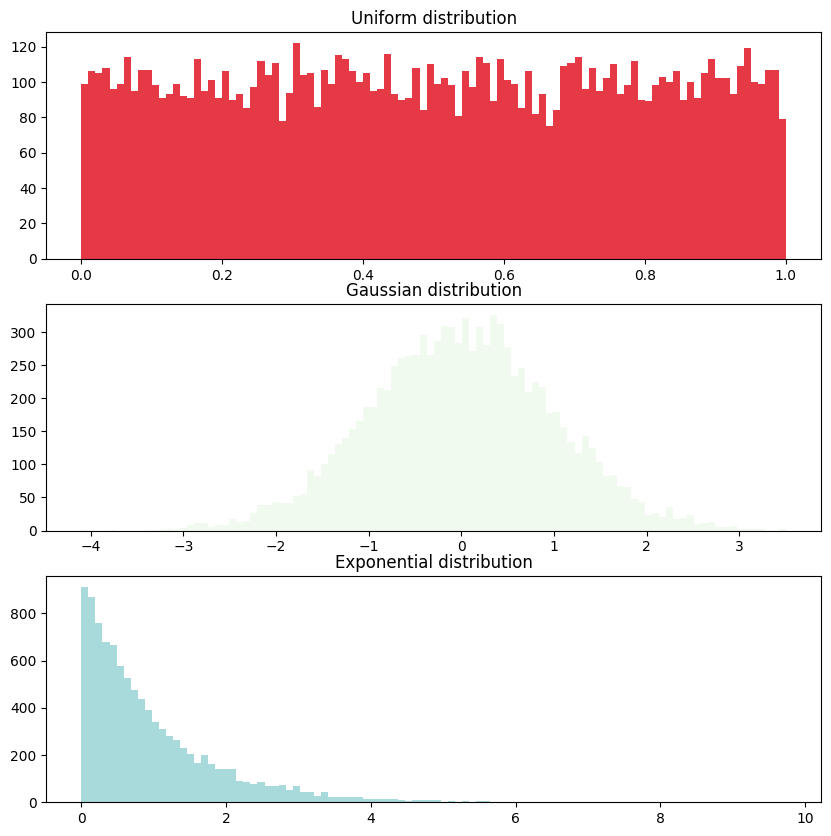

In [222]:
uniform, gaussian, exponential = random_number(10000)

# Plotting
fig, ax = plt.subplots(3, 1, figsize = (10, 10))
ax[0].hist(uniform, bins = 100, color = colors[0])
ax[0].set_title('Uniform distribution')
ax[1].hist(gaussian, bins = 100, color = colors[1])
ax[1].set_title('Gaussian distribution')
ax[2].hist(exponential, bins = 100, color = colors[2])
ax[2].set_title('Exponential distribution')

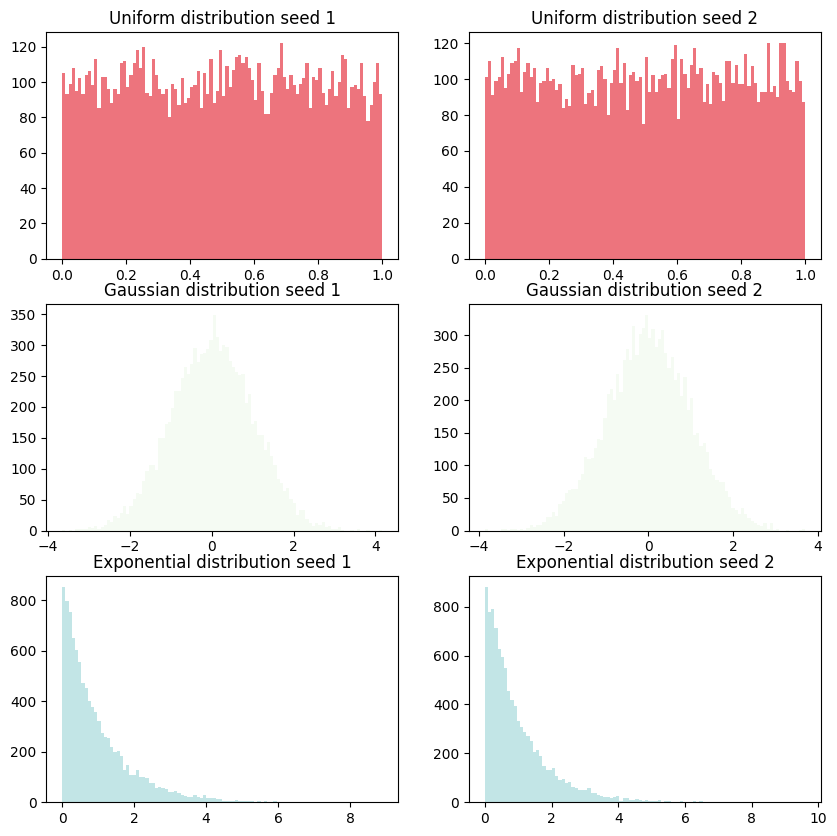

In [223]:
# Tesing how a "seed" option works and changes the random numbers
""" The seed is a number that is used to initialize the random number generator. So if should not change anything, when we generate a lot of random numbers. """

def random_number_seed(dimensions, seed):
    np.random.seed(seed)
    uniform = np.random.rand(dimensions)
    gaussian = np.random.randn(dimensions)
    exponential = np.random.exponential(1, dimensions)
    return uniform, gaussian, exponential

uniform_seed, gaussian_seed, exponential_seed = random_number_seed(10000, 1)
uniform_seed_2, gaussian_seed_2, exponential_seed_2 = random_number_seed(10000, 1234)

# Plotting
fig, ax = plt.subplots(3, 2, figsize = (10, 10))
ax[0, 0].hist(uniform_seed, bins = 100, color = colors[0], alpha = 0.7)
ax[0, 0].set_title('Uniform distribution seed 1')
ax[1, 0].hist(gaussian_seed, bins = 100, color = colors[1], alpha = 0.7)
ax[1, 0].set_title('Gaussian distribution seed 1')
ax[2, 0].hist(exponential_seed, bins = 100, color = colors[2], alpha = 0.7)
ax[2, 0].set_title('Exponential distribution seed 1')

ax[0, 1].hist(uniform_seed_2, bins = 100, color = colors[0], alpha = 0.7)
ax[0, 1].set_title('Uniform distribution seed 2')
ax[1, 1].hist(gaussian_seed_2, bins = 100, color = colors[1], alpha = 0.7)
ax[1, 1].set_title('Gaussian distribution seed 2')
ax[2, 1].hist(exponential_seed_2, bins = 100, color = colors[2], alpha = 0.7)
ax[2, 1].set_title('Exponential distribution seed 2')

plt.show()

In [224]:
# Testing if it takes 10 times longer to generate 10 times more numbers
import time

def random_number_time(dimensions):
    start = time.time()
    uniform = np.random.rand(dimensions)
    gaussian = np.random.randn(dimensions)
    exponential = np.random.exponential(1, dimensions)
    end = time.time()
    return end - start

time_1 = random_number_time(10000)
time_2 = random_number_time(100000)
time_3 = random_number_time(1000000)

print('Time for 10000 numbers: ', time_1)
print('Time for 100000 numbers: ', time_2)
print('Time for 1000000 numbers: ', time_3)

Time for 10000 numbers:  0.0005700588226318359
Time for 100000 numbers:  0.004463911056518555
Time for 1000000 numbers:  0.04044198989868164


## Exercise 1: Classic and Simple Monte Carlo Usage

Estimated area of a circle with given radius:  84.92398720000001
Analytical area of a circle with given radius:  84.94866535306801


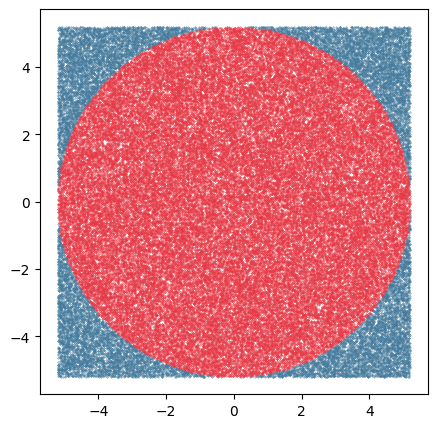

In [225]:
# Estimating the area of a circle using random numbers and Monte Carlo method (Acceptance-Rejection method)
def circle_area(radius, N):
    x = np.random.uniform(-radius, radius, N)
    y = np.random.uniform(-radius, radius, N)
    r = np.sqrt(x**2 + y**2)
    inside = r[r < radius]
    area = 4 * radius**2 * len(inside) / N

    accepted_points = np.column_stack((x, y))[r < radius]
    accepted = accepted_points
    rejected_points = np.column_stack((x, y))[r >= radius]
    rejected = rejected_points

    return area, len(inside), x, y, r, accepted, rejected

area, inside, x, y, r, accepted, rejected = circle_area(5.2, 100000)

print('Estimated area of a circle with given radius: ', area)
print('Analytical area of a circle with given radius: ', np.pi * 5.2**2)

# Plotting the accepted and rejected points
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
ax.scatter(rejected[:, 0], rejected[:, 1], color = colors[3], s = 0.1)
ax.scatter(accepted[:, 0], accepted[:, 1], color = colors[0], s = 0.1)
plt.show();

Estimated area of a circle with given radius in 1D:  10.4
Analytical area of a circle with given radius in 1D:  10.4


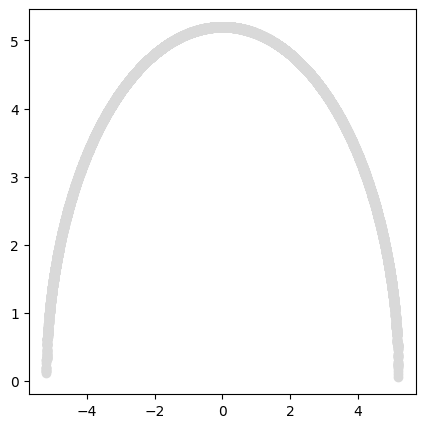

In [226]:
# Trying to estimate the area using the same Monte Carlo method, but in 1-dimension - NOT WORKING
def circle_area_1D(radius, N):
    x = np.random.uniform(-radius, radius, N)
    y = np.sqrt(radius**2 - x**2)

    inside = y[y < radius]
    area = 2 * radius * len(inside) / N

    accepted_points = np.column_stack((x, y))[y < radius]
    accepted = accepted_points
    rejected_points = np.column_stack((x, y))[y >= radius]
    rejected = rejected_points

    return area, len(inside), x, r, accepted, rejected

area_1D, inside_1D, x_1D, r_1D, accepted_1D, rejected_1D = circle_area_1D(5.2, 10000)

print('Estimated area of a circle with given radius in 1D: ', area_1D)
print('Analytical area of a circle with given radius in 1D: ', 2 * 5.2)

# Plotting the accepted and rejected points in 1D
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
ax.scatter(rejected_1D[:, 0], rejected_1D[:, 1], color = '#d9d9d9')
ax.scatter(accepted_1D[:, 0], accepted_1D[:, 1], color = '#d9d9d9')

## Exercise 2: Random Number Generator

In [227]:
# Making a 1000 estimates of the area of a circle with a given radius, with 100 tests/trials/points each
areas = []
for i in range(1000):
    area, inside, x, y, r, accepted, rejected = circle_area(5.2, 100)
    areas.append(area)
    print('Estimated area of a circle with given radius: ', area)

Estimated area of a circle with given radius:  83.28320000000002
Estimated area of a circle with given radius:  87.60960000000001
Estimated area of a circle with given radius:  82.20160000000001
Estimated area of a circle with given radius:  83.28320000000002
Estimated area of a circle with given radius:  86.528
Estimated area of a circle with given radius:  86.528
Estimated area of a circle with given radius:  85.44640000000001
Estimated area of a circle with given radius:  87.60960000000001
Estimated area of a circle with given radius:  88.69120000000001
Estimated area of a circle with given radius:  83.28320000000002
Estimated area of a circle with given radius:  78.95680000000002
Estimated area of a circle with given radius:  84.36480000000002
Estimated area of a circle with given radius:  85.44640000000001
Estimated area of a circle with given radius:  85.44640000000001
Estimated area of a circle with given radius:  85.44640000000001
Estimated area of a circle with given radius:  

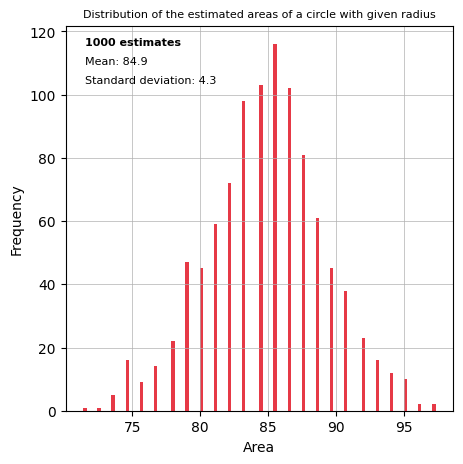

In [228]:
# Plotting the distribution of the estimated areas
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
ax.hist(areas, bins = 100, color = colors[0])
ax.set_title('Distribution of the estimated areas of a circle with given radius', fontsize = 8)
ax.annotate('1000 estimates', xy = (0.05, 0.95), xycoords = 'axes fraction', fontsize = 8, fontweight = 'bold')
ax.annotate(f'Mean: {np.mean(areas):.1f}', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)
ax.annotate(f'Standard deviation: {np.std(areas):.1f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=8)
ax.set_xlabel('Area')
ax.set_ylabel('Frequency')
ax.grid(True, which = 'both', linestyle = '-', linewidth = 0.5)
plt.show();

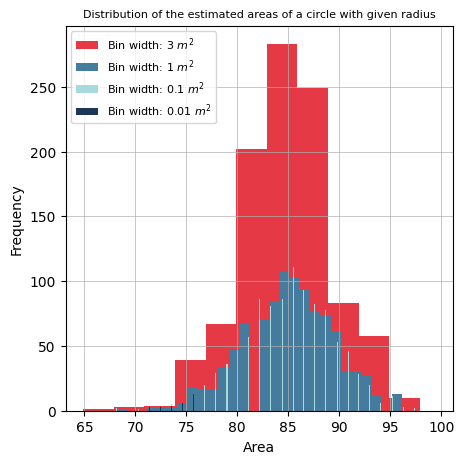

In [229]:
# Plotting three trials, where the bin width is 3 m^2, 1 m^2 and 0.1 m^2 respectively in the same plot 
areas_3 = []
areas_1 = []
areas_01 = []
areas_0001 = []

for i in range(1000):
    area_3, inside_3, x_3, y_3, r_3, accepted_3, rejected_3 = circle_area(5.2, 100)
    areas_3.append(area_3)

    area_1, inside_1, x_1, y_1, r_1, accepted_1, rejected_1 = circle_area(5.2, 100)
    areas_1.append(area_1)

    area_01, inside_01, x_01, y_01, r_01, accepted_01, rejected_01 = circle_area(5.2, 100)
    areas_01.append(area_01)

    area_0001, inside_0001, x_0001, y_0001, r_0001, accepted_0001, rejected_0001 = circle_area(5.2, 100)
    areas_0001.append(area_0001)

binwidths = [3, 1, 0.1, 0.01]

# Plotting the distribution of the estimated areas
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
ax.hist(areas_3, bins = np.arange(min(areas_3), max(areas_3), binwidths[0]), color = colors[0], label = f'Bin width: 3 $m^2$')
ax.hist(areas_1, bins = np.arange(min(areas_1), max(areas_1), binwidths[1]), color = colors[3], label = f'Bin width: 1 $m^2$')
ax.hist(areas_01, bins = np.arange(min(areas_01), max(areas_01), binwidths[2]), color = colors[2], label = f'Bin width: 0.1 $m^2$')
ax.hist(areas_0001, bins = np.arange(min(areas_0001), max(areas_0001), binwidths[3]), color = colors[4], label = f'Bin width: 0.01 $m^2$')
ax.set_title('Distribution of the estimated areas of a circle with given radius', fontsize = 8)
ax.set_xlabel('Area')
ax.set_ylabel('Frequency')
ax.legend(loc = 'upper left', fontsize = 8)
ax.grid(True, which = 'both', linestyle = '-', linewidth = 0.5)
plt.show();

We get the gaps, since our generator is discrete now that we sample the area in this way. This might not be an issue, if we use another method. 

## Exercise 3: Calculate the Precision of Pi

In [230]:
# Function for estimating pi using the area and a different number of points
def estimate_pi(radius, N):
    area, inside, x, y, r, accepted, rejected = circle_area(radius, N)
    pi = area / radius**2
    #print('Estimate of pi: ', pi, 'with ', N, 'points')
    return pi

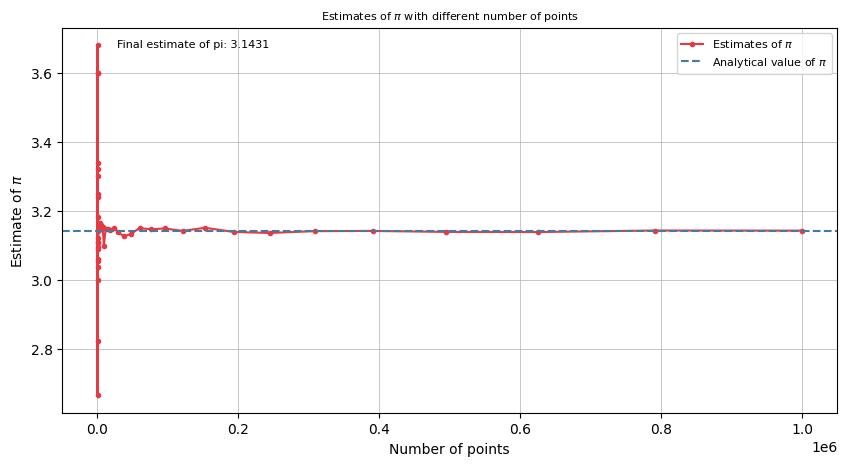

In [241]:
# Plotting estimates of pi with different number of points as a function of the number of points
N = np.logspace(1, 6, 50, base = 10, dtype = int)
pi = [estimate_pi(5.2, n) for n in N]

fig, ax = plt.subplots(1, 1, figsize = (10, 5))
ax.plot(N, pi, color = colors[0], marker = 'o', label = f'Estimates of $\pi$', markersize = 3)
ax.set_title(f'Estimates of $\pi$ with different number of points', fontsize = 8)
ax.annotate(f'Final estimate of pi: {pi[-1]:.4f}', xy = (0.07, 0.95), xycoords = 'axes fraction', fontsize = 8)
ax.set_xlabel('Number of points')
ax.set_ylabel(f'Estimate of $\pi$')
ax.axhline(y = np.pi, color = colors[3], linestyle = '--', label = 'Analytical value of $\pi$')
ax.grid(True, which = 'both', linestyle = '-', linewidth = 0.5)
ax.legend(loc = 'best', fontsize = 8)
plt.show();